In [1]:
import torch

from perspective import Retina, Monitor, Perspective

from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout

import matplotlib.pyplot as plt

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = ['/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip', ]

dataset_fn = 'sensorium.datasets.static_loaders'
dataset_config = {'paths': filenames,
                 'normalize': True,
                 'include_behavior': False,
                 'include_eye_position': True,
                 'batch_size': 128,
                 'scale': 0.25,
                 }

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 0.0076,
  'hidden_kern': 7,
  'hidden_channels': 64,
  'depth_separable': True,
  'grid_mean_predictor': {'type': 'cortex',
   'input_dimensions': 2,
   'hidden_layers': 1,
   'hidden_features': 30,
   'final_tanh': True},
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': False,
}

#perspective = Perspective(Retina(device=device), Monitor(device=device)).to(device)
model_config['perspective'] = True

In [4]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [5]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {'max_iter': 200,
                 'verbose': False,
                 'lr_decay_steps': 4,
                 'avg_loss': False,
                 'lr_init': 0.009,
                 'track_training': False,
                 }

trainer_config['device'] = 'cuda:7'

trainer = get_trainer(trainer_fn=trainer_fn, 
                     trainer_config=trainer_config)

In [6]:
validation_score, trainer_output, state_dict = trainer(model, dataloaders, seed=random_seed)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 85: 100%|██████████| 35/35 [00:03<00:00, 10.98it/s]


In [7]:
validation_score

np.float32(0.3425628)

In [8]:
list(model.perspective.parameters())

[Parameter containing:
 tensor([-0.3883,  0.1467, -0.7106, -0.8253,  0.1544, -0.4598, -0.0433, -0.0631,
         -0.5995,  0.1832, -0.9504, -0.8851, -0.0174, -0.8999,  0.3505, -0.4143],
        device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[0.4807],
         [0.3096],
         [0.9204],
         [0.5965],
         [0.4476],
         [0.7564],
         [0.6407],
         [0.6280],
         [0.4171],
         [0.5508],
         [0.5879],
         [0.3468],
         [0.5197],
         [0.6739],
         [0.5847],
         [0.5981]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[ 0.4900, -0.6660],
         [-0.7176, -0.1690],
         [ 1.3079,  0.0307],
         [ 0.6946, -0.7201],
         [ 0.3409, -0.5840],
         [ 0.4133,  0.7888],
         [-0.3623, -0.7925],
         [ 0.2017,  0.7891],
         [ 0.3776,  0.2195],
         [ 1.0426, -0.1797],
         [ 0.5096,  0.2790],
         [ 0.3956,  0.2385],
         [ 0.2938, -0.8032],
  

img shape: torch.Size([128, 36, 64])
perspective output shape: torch.Size([128, 36, 54])


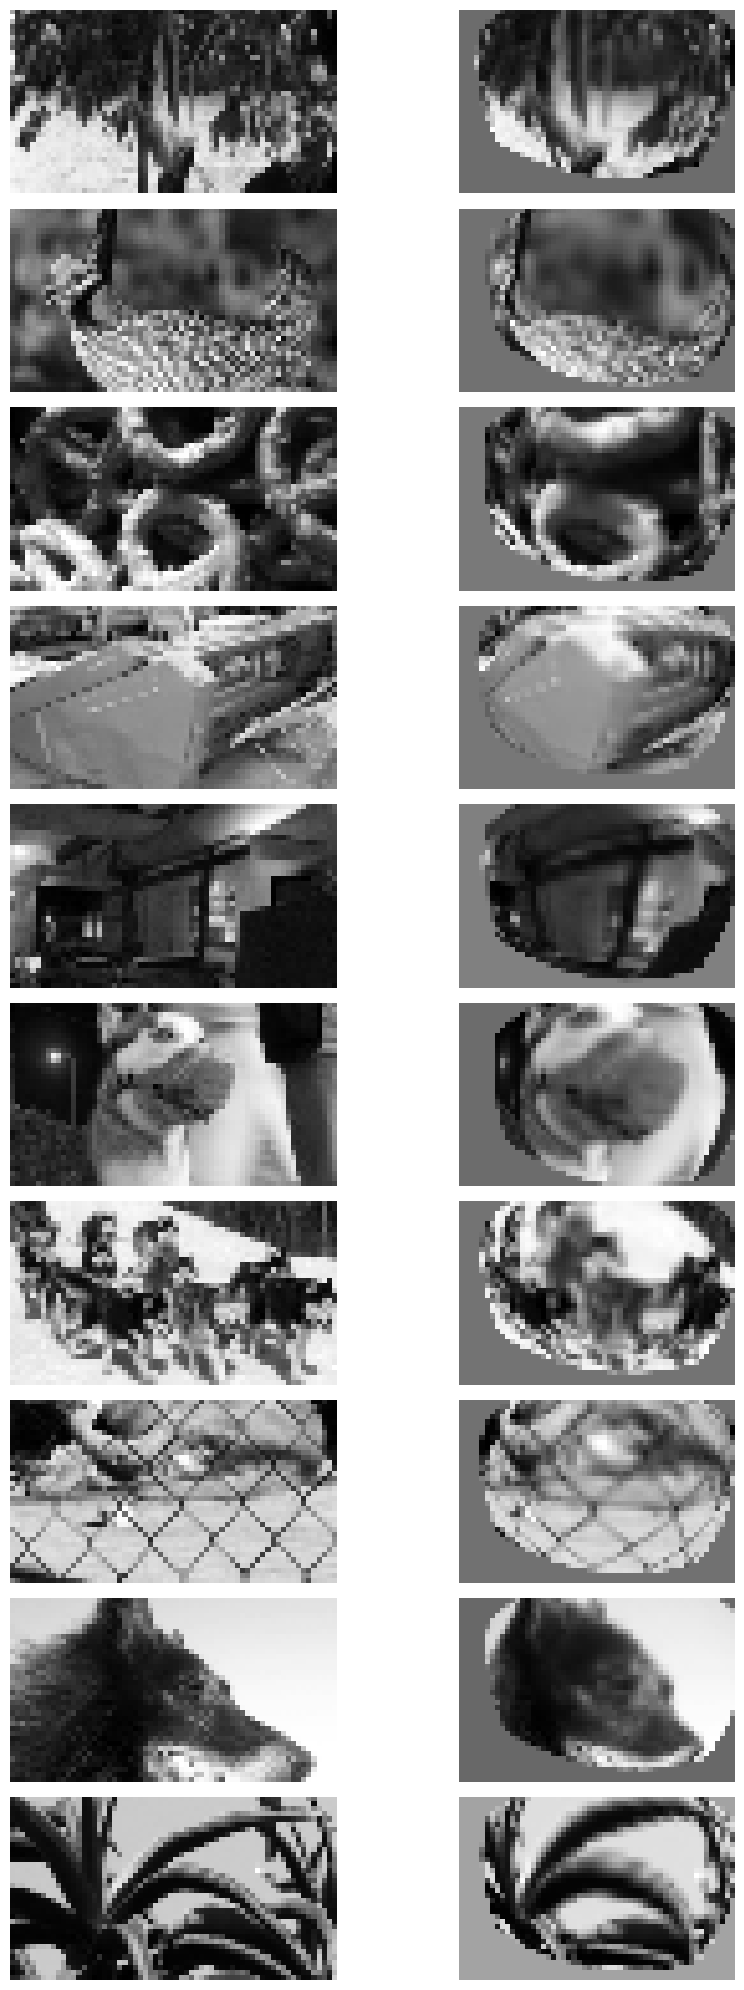

In [9]:
data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

imgs = batch.images[:, 0].detach().cpu()
out =model.perspective(batch.images, batch.pupil_center)[:, 0].detach().cpu()
print('img shape:', imgs.shape)
print('perspective output shape:', out.shape)

for i in range(10):
    ax[i, 0].imshow(imgs[i], cmap='gray')
    ax[i, 0].axis('off')
    ax[i, 1].imshow(out[i], cmap='gray')
    ax[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
model.perspective.retina.mlp

Sequential(
  (0): ParametrizedLinear(
    in_features=2, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (1): GELU(approximate='none')
  (2): Scale()
  (3): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (4): GELU(approximate='none')
  (5): Scale()
  (6): ParametrizedLinear(
    in_features=16, out_features=16, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
  (7): GELU(approximate='none')
  (8): Scale()
  (9): ParametrizedLinear(
    in_features=16, out_features=3, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _WeightNorm()
      )
    )
  )
)

In [11]:
model.perspective.retina.mlp(batch.pupil_center)

tensor([[ 1.0114e-03, -7.7963e-02, -1.3869e-01],
        [ 7.6810e-02, -1.5613e-01, -1.5969e-01],
        [ 5.3536e-02, -1.2255e-01, -1.5911e-01],
        [ 1.6523e-02, -7.5985e-02, -1.4842e-01],
        [ 6.4707e-02, -1.1291e-01, -1.6071e-01],
        [ 1.4613e-01, -2.1240e-01, -1.7558e-01],
        [ 2.6250e-02, -1.1784e-01, -1.4485e-01],
        [ 5.2061e-02, -1.0211e-01, -1.5955e-01],
        [ 1.9694e-02, -1.7168e-01, -1.3657e-01],
        [ 6.0519e-02, -1.1335e-01, -1.6104e-01],
        [-1.8156e-02, -8.0113e-02, -1.2564e-01],
        [ 1.3946e-02,  6.5854e-03, -1.5327e-01],
        [ 2.5657e-02, -9.8464e-02, -1.4879e-01],
        [ 4.5049e-02, -1.0221e-01, -1.5773e-01],
        [ 1.1373e-01, -1.5865e-01, -1.5803e-01],
        [ 4.1896e-02, -9.2252e-02, -1.5732e-01],
        [ 1.0773e-01, -1.5831e-01, -1.5699e-01],
        [ 3.9018e-02, -8.3373e-02, -1.5683e-01],
        [ 4.1309e-02, -1.0431e-01, -1.5598e-01],
        [ 2.4768e-02, -9.0320e-02, -1.5007e-01],
        [ 5.3335e-02

seed 41 results:  
    Parameter containing:  
    tensor([-0.2717,  0.1146,  1.2536], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.5564,  0.5958, -0.2947], device='cuda:7', requires_grad=True)  

seed 40 results:  
    Parameter containing:  
    tensor([-0.4187,  0.2635,  1.1136], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.7092,  0.4121, -0.6947], device='cuda:7', requires_grad=True)  

seed 39 results:  
    Parameter containing:  
    tensor([-0.4425, -0.2122,  1.1337], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([-0.2125,  0.5381,  0.8054], device='cuda:7', requires_grad=True)  